# Multichannel and fluorescence images in spatialdata-plot

A fluorescence or multiplexed-imaging experiment (Xenium morphology, CODEX, IMC, CyCIF) produces an
image with **several channels** — one per stain or marker — rather than a single RGB photo.
`render_images` renders these directly, and gives you per-channel control over which channels to show,
what colour each gets, and how each is contrasted. By the end you should be able to:

- Inspect an image's named channels and render a single one by name.
- Composite several channels at once and give each its own colour with `palette` (a lookup table, or LUT).
- Fix the dim, heavy-tailed look of raw fluorescence with per-channel contrast.
- Use `grayscale` and `channels_as_legend` to finish a publication-ready panel.

We use the Xenium `cells` dataset from `squidpy` (`morphology_focus` is a real four-channel
fluorescence image), downloaded and cached on first use.

## Setup

In [1]:
import squidpy as sq

import spatialdata_plot  # noqa: F401  # registers the .pl accessor
from spatialdata_plot import PercentileNormalize

sdata = sq.datasets.cells()
sdata

INFO     Loading existing dataset from data/spatialdata/cells.zarr                                                 


SpatialData object, with associated Zarr store: /Users/tim.treis/Documents/GitHub/spatialdata-plot-notebooks/tutorials/data/spatialdata/cells.zarr
├── Images
│     ├── 'he_aligned': DataTree[cyx] (3, 430, 540), (3, 215, 270)
│     ├── 'he_image': DataTree[cyx] (3, 423, 339), (3, 211, 169)
│     └── 'morphology_focus': DataTree[cyx] (4, 430, 540), (4, 215, 270)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (430, 540), (215, 270)
│     ├── 'nucleus_labels': DataTree[yx] (430, 540), (215, 270)
│     └── 'tissue_labels': DataTree[yx] (430, 540), (215, 270)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (94, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (94, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (94, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        he_aligned (Images), he_image (Images), morphology_focus (Images), cell_labels (Labels)

## 1. Inspect the channels

A multichannel image carries a named channel axis. Here are the four markers of the Xenium
`morphology_focus` image.

In [2]:
image = sdata.images["morphology_focus"]
# multiscale images are a datatree; read the channel names off the full-resolution level
full_res = image["scale0"].image if hasattr(image, "keys") else image
channels = [str(c) for c in full_res.coords["c"].values]
channels

['DAPI', 'ATP1A1/CD45/E-Cadherin', '18S', 'AlphaSMA/Vimentin']

## 2. A single channel — `channel=`

Pass a channel **name** to render just that marker — channels are selected by name. (An integer
works only when the channel axis is itself integer-named, as in the synthetic `blobs` image; the
named markers here must be selected by name.) `DAPI` stains nuclei.

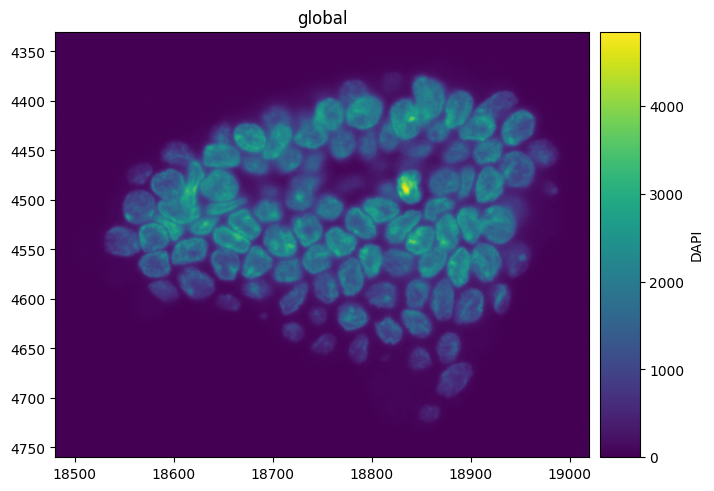

In [3]:
sdata.pl.render_images("morphology_focus", channel="DAPI").pl.show()

## 3. The default composite

With no `channel`, all channels are composited into one image, each assigned a colour automatically.
This already shows the tissue structure.

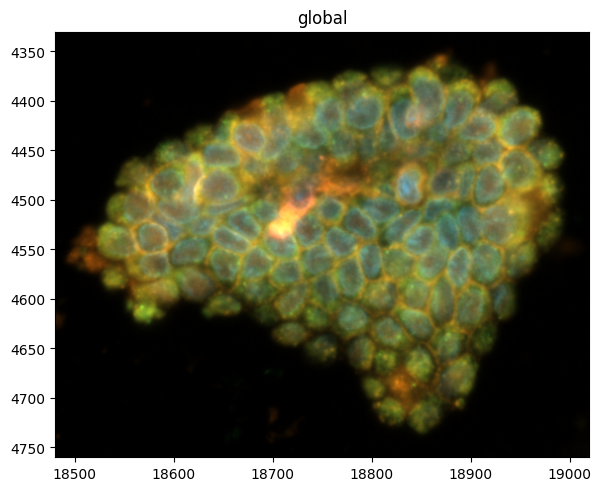

In [4]:
sdata.pl.render_images("morphology_focus").pl.show()

## 4. Per-channel contrast — the fluorescence essential

Raw fluorescence is **heavy-tailed**: a few bright pixels stretch the range and crush everything else
toward black. Pass a **list** of norms — one per channel — to set contrast independently.
`PercentileNormalize` clips to data percentiles, which is exactly what viewers like Xenium Explorer do.
See the *Normalization and contrast* tutorial for norms in depth.

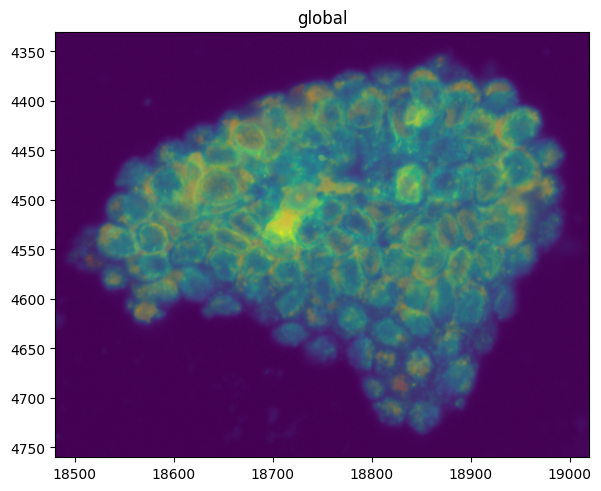

In [5]:
norms = [PercentileNormalize(1, 99)] * len(channels)
sdata.pl.render_images("morphology_focus", norm=norms).pl.show()

## 5. Recolouring channels — `cmap` vs `palette`

You can hand each channel its own colourmap with a list of `cmap`s. For fluorescence this emits a
warning: colourmaps run to **white**, so overlapping channels wash each other out. For additive
compositing, prefer `palette` (next section).

Mechanically, a `cmap` list *averages* the channels (dividing by their count), which dims the
result, whereas `palette` *adds* them — the source of the cleaner composite in the next section.

WARNING  render_images: You're blending multiple cmaps. If the plot doesn't look like you expect, it might be      
         because your cmaps go from a given color to 'white', and not to 'transparent'. Therefore, the 'white' of  
         higher layers will overlay the lower layers. Consider using 'palette' instead.                            


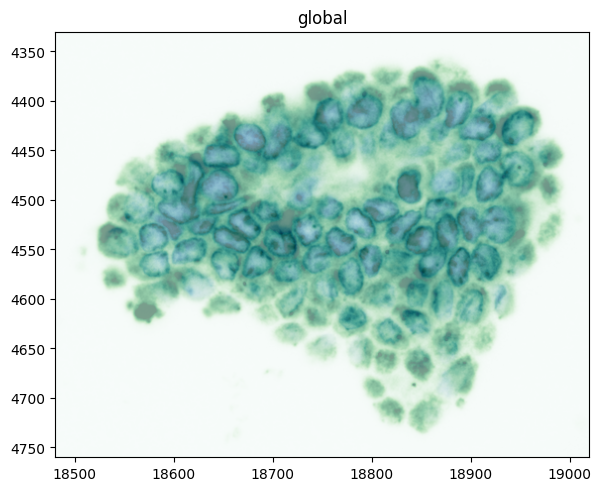

In [6]:
sdata.pl.render_images(
    "morphology_focus",
    channel=["DAPI", "18S"],
    cmap=["Blues", "Greens"],
    norm=[PercentileNormalize(1, 99)] * 2,
).pl.show()

## 6. Fluorescence LUTs — per-channel `palette`

`palette` assigns each channel a single colour that fades to **black**, and the channels are then added
together, so they combine cleanly — the lookup-table (LUT) model used in microscopy. Assign a colour per marker to build a
readable composite.

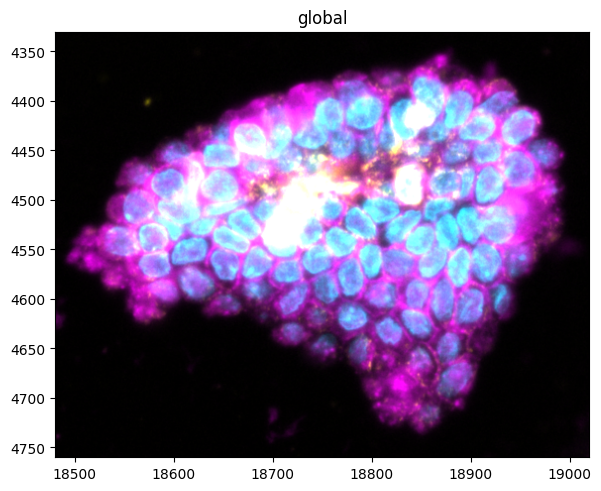

In [7]:
sdata.pl.render_images(
    "morphology_focus",
    channel=["DAPI", "ATP1A1/CD45/E-Cadherin", "AlphaSMA/Vimentin"],
    palette=["cyan", "magenta", "yellow"],
    norm=[PercentileNormalize(1, 99)] * 3,
).pl.show()

## 7. A desaturated view — `grayscale`

`grayscale=True` collapses a **three-channel** selection into a single grayscale intensity — useful
for a structural, colour-free view. It requires exactly three channels, and takes a single `norm`
(broadcast across them) rather than a per-channel list.

The three channels are mapped to red, green and blue and combined with the standard luminance
weights (Rec. 601: 0.299 / 0.587 / 0.114), so **the order you list them in changes the result**. Those
weights are tuned for natural RGB photographs, not fluorescence, so read the grayscale view as
structural rather than quantitative. A selection that is not exactly three channels raises an error.

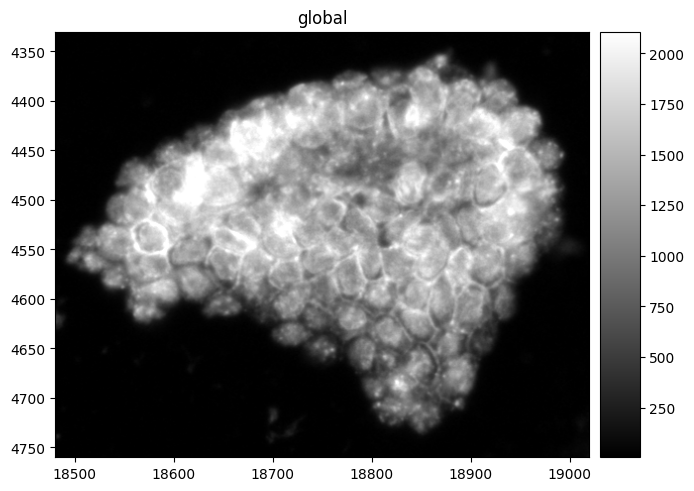

In [8]:
sdata.pl.render_images(
    "morphology_focus",
    channel=["DAPI", "ATP1A1/CD45/E-Cadherin", "18S"],
    grayscale=True,
    norm=PercentileNormalize(1, 99),
).pl.show()

## 8. Labelling the composite — `channels_as_legend`

`channels_as_legend=True` adds a legend mapping each channel to its compositing colour. It needs
distinct per-channel colours — pass `palette` (or a list of `cmap`s); with the default composite or
a single shared `cmap` there is nothing to map, and the flag is ignored with a warning.

Prefer `palette` here: sequential colormaps like `Blues`/`Reds`/`Greens` run from *white* to colour,
so blending several of them washes the composite out, whereas `palette` colours are additive on black.


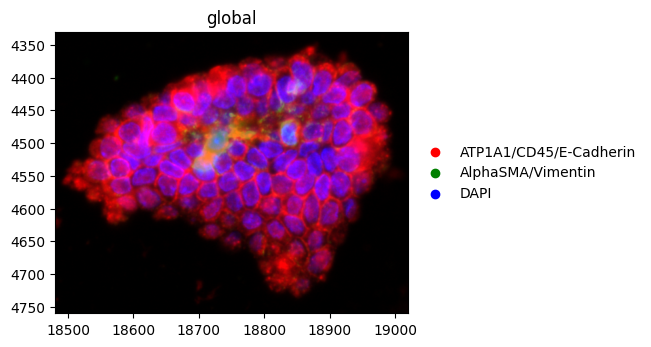

In [9]:
sdata.pl.render_images(
    "morphology_focus",
    channel=["DAPI", "ATP1A1/CD45/E-Cadherin", "AlphaSMA/Vimentin"],
    palette=["blue", "red", "green"],
    norm=[PercentileNormalize(1, 99)] * 3,
    channels_as_legend=True,
).pl.show()


## Summary

- A multichannel image has a **named channel axis**; render one with `channel="name"` or composite
  several by passing a list (or omitting `channel`).
- Fluorescence is heavy-tailed — pass a **list of norms** (`PercentileNormalize` per channel) so each
  marker is contrasted independently.
- For additive fluorescence compositing use `palette` (colour-to-black additive LUTs), not `cmap`
  (colour-to-white), which washes overlapping channels out.
- `grayscale` gives a colour-free three-channel view; `channels_as_legend` labels the composite.

## For reproducibility

In [10]:
# ruff: noqa: F401, F811, I001, E402
# fmt: off
import warnings
import spatialdata_plot

%load_ext watermark
# fmt: on

%watermark -v -m -p spatialdata,spatialdata_plot,squidpy,matplotlib,numpy

Python implementation: CPython
Python version       : 3.14.4
IPython version      : 9.13.0

spatialdata     : 0.7.3
spatialdata_plot: 0.4.1
squidpy         : 1.8.3
matplotlib      : 3.10.9
numpy           : 2.4.4

Compiler    : Clang 20.1.8 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

